<a href="https://colab.research.google.com/github/RBOM12/tpValorisationdeladonn-es/blob/main/TP1_BROCHET_Valorisation_de_la_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 1 Valorisation de la données




## Réduction de dimension

In [ ]:
# Différents import pour la réduction et la visualisation des données
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_circles
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

(1797, 64)


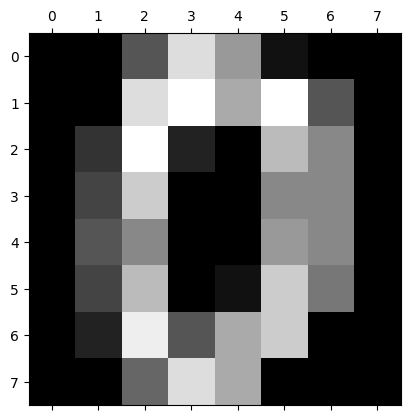

In [ ]:
data = load_digits();
print(data.data.shape)
plt.matshow(data.images[0], cmap="gray")
plt.show()

In [ ]:
X, y = load_digits(return_X_y=True)

# Check the size and number of dimensions using the shape attribute
print(f"Shape of X (observations): {X.shape}")
print(f"Shape of y (labels): {y.shape}")

Shape of X (observations): (1797, 64)
Shape of y (labels): (1797,)


La taille du jeu de données est donc de 1797 et sa dimension est de 64 .

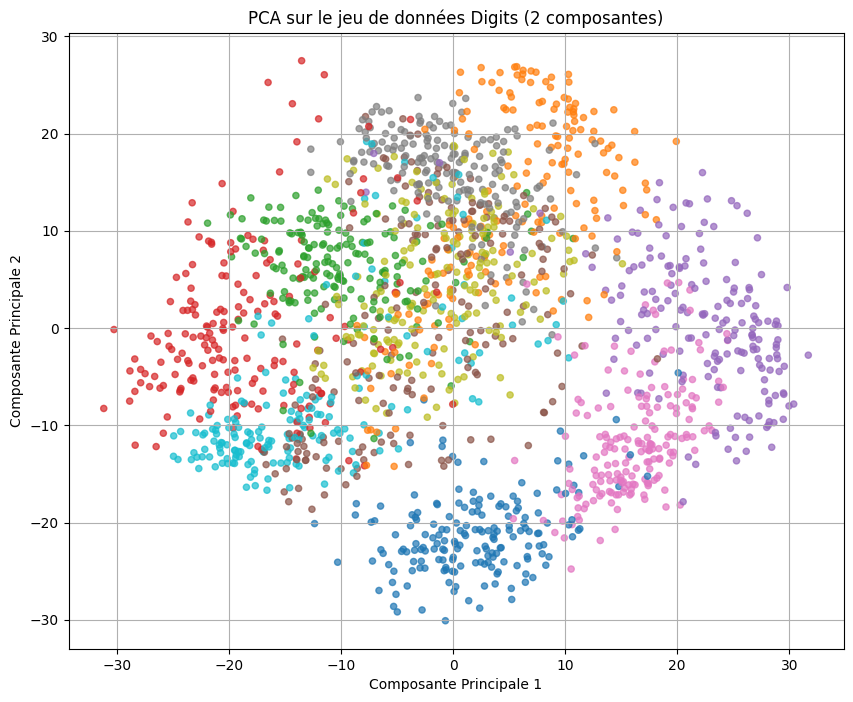

In [ ]:
# 2. Appliquer la PCA (deux composantes) sur le jeu de données digits
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Afficher le résultat de la PCA en utilisant matplotlib
plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=20)

plt.title("PCA sur le jeu de données Digits (2 composantes)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.grid(True)
plt.show()

4) Les groupes sont plutot mal séparer avec de nombreux groupes qui se chevauche et se confonde. On reparque tout de même des régions bien distincte des autres comme le bleu et le rose du bas.

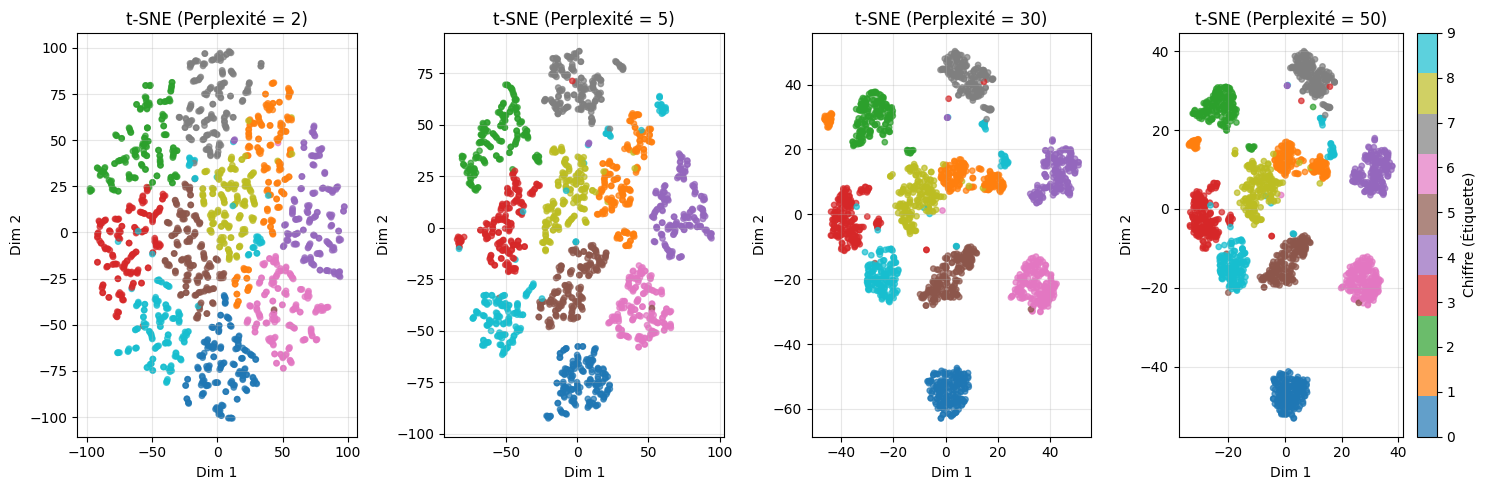

In [ ]:
# Values of perplexity to test
perplexities = [2, 5, 30, 50]

# Set up the matplotlib figure
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexities):
    # Initialize t-SNE with 2 components and the current perplexity
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)

    # Fit and transform the dataset X
    X_tsne = tsne.fit_transform(X)

    # Create a subplot for each perplexity value
    plt.subplot(1, 4, i + 1)

    # Plot the results, coloring by the true labels (y)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
    plt.title(f"t-SNE (Perplexité = {perplexity})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True, alpha=0.3)

# Add a single colorbar for the whole figure to identify the digits
plt.colorbar(scatter, ticks=range(10), label='Chiffre (Étiquette)')
plt.tight_layout()
plt.show()

6. On se rend compte que plus la perplexité est haute plus les groupes sont compact et différents. On retrouve néanmoins quelque intrus qui se retouve loin de leurs groupes



## Clustering

1.


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

# 1. Initialisation des modèles de clustering
# K-Means avec k=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')

# DBSCAN avec ses paramètres par défaut (eps=0.5, min_samples=5)
dbscan = DBSCAN()

# 2. Application sur les résultats de la PCA (Question 2)
y_kmeans_pca = kmeans.fit_predict(X_pca)
y_dbscan_pca = dbscan.fit_predict(X_pca)

# 3. Application sur les résultats du t-SNE (Question 5)
# (Assurez-vous d'utiliser un de vos résultats t-SNE, par exemple celui avec perplexité=30)
y_kmeans_tsne = kmeans.fit_predict(X_tsne)
y_dbscan_tsne = dbscan.fit_predict(X_tsne)

# 4. Calcul de l'Adjusted Rand Index (ARI)
ari_kmeans_pca = adjusted_rand_score(y, y_kmeans_pca)
ari_dbscan_pca = adjusted_rand_score(y, y_dbscan_pca)

ari_kmeans_tsne = adjusted_rand_score(y, y_kmeans_tsne)
ari_dbscan_tsne = adjusted_rand_score(y, y_dbscan_tsne)

# 5. Affichage et comparaison des résultats
print("--- Comparaison des ARI ---")
print(f"K-Means sur PCA    : {ari_kmeans_pca:.4f}")
print(f"DBSCAN sur PCA     : {ari_dbscan_pca:.4f}")
print(f"K-Means sur t-SNE  : {ari_kmeans_tsne:.4f}")
print(f"DBSCAN sur t-SNE   : {ari_dbscan_tsne:.4f}")

--- Comparaison des ARI ---
K-Means sur PCA    : 0.3603
DBSCAN sur PCA     : 0.0002
K-Means sur t-SNE  : 0.7974
DBSCAN sur t-SNE   : 0.0009


2.

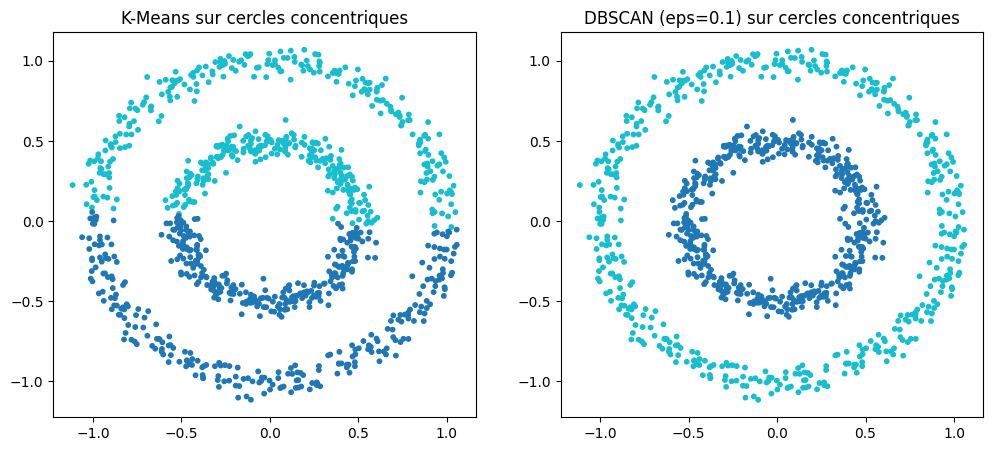

In [ ]:
# Générer le jeu de données contenant deux cercles concentriques
X_circles, y_circles = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=42)

# Appliquer K-Means (k=2 car on a visuellement 2 cercles)
kmeans_c = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans_c = kmeans_c.fit_predict(X_circles)

# Appliquer DBSCAN
dbscan_c = DBSCAN(eps=0.1, min_samples=5)
y_dbscan_c = dbscan_c.fit_predict(X_circles)

# Visualisation des résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_kmeans_c, cmap='tab10', s=10)
axes[0].set_title("K-Means sur cercles concentriques")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_dbscan_c, cmap='tab10', s=10)
axes[1].set_title("DBSCAN (eps=0.1) sur cercles concentriques")

plt.show()

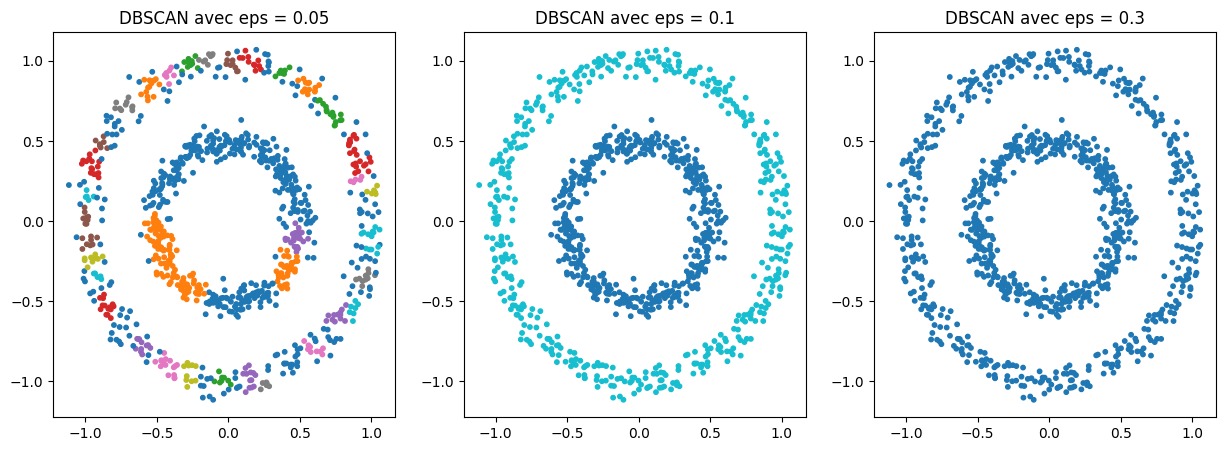

In [ ]:
# Définir différentes valeurs de epsilon à tester
eps_values = [0.05, 0.1, 0.3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, eps in enumerate(eps_values):
    # Appliquer DBSCAN avec la valeur eps courante
    dbs = DBSCAN(eps=eps, min_samples=5)
    y_dbs = dbs.fit_predict(X_circles)

    # Visualiser
    axes[i].scatter(X_circles[:, 0], X_circles[:, 1], c=y_dbs, cmap='tab10', s=10)
    axes[i].set_title(f"DBSCAN avec eps = {eps}")

plt.show()

eps trop petit (0.05) : Les points sont trop loin les uns des autres pour être considérés comme "voisins".

eps idéal (0.1) : La distance est suffisante pour relier les points d'un même cercle, mais assez petite pour ne pas "sauter" le vide entre les deux cercles. On a bien 2 clusters.

eps trop grand (0.3) : La distance de voisinage est plus grande que l'espace vide entre les deux cercles.

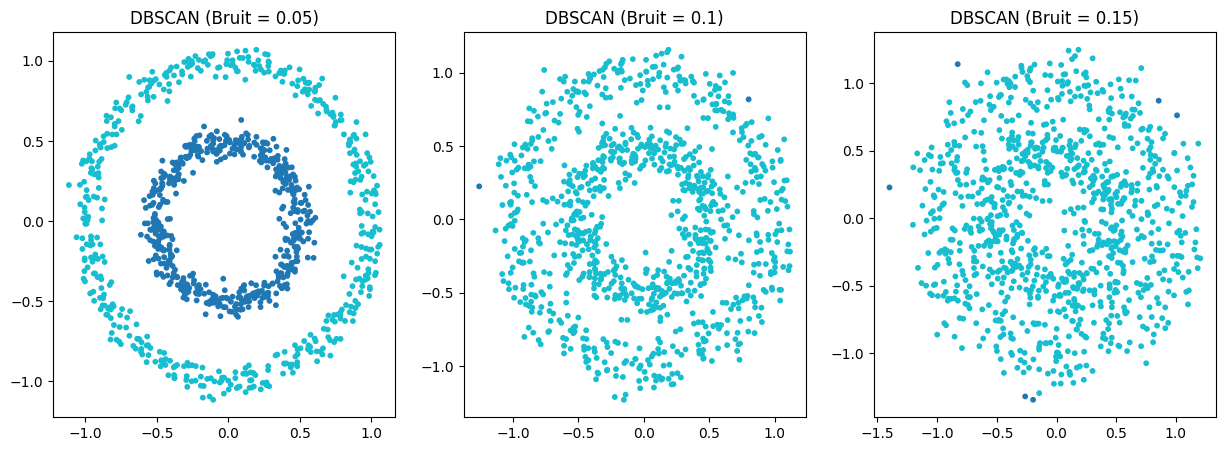

In [ ]:
# Différentes valeurs de bruit
noise_values = [0.05, 0.10, 0.15]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, noise in enumerate(noise_values):
    # Regénérer les données avec plus de bruit
    X_noise, y_noise = make_circles(n_samples=1000, factor=0.5, noise=noise, random_state=42)

    # Appliquer DBSCAN (On fixe un eps à 0.15 pour compenser le bruit)
    dbs_noise = DBSCAN(eps=0.15, min_samples=5)
    y_dbs_noise = dbs_noise.fit_predict(X_noise)

    # Visualiser
    axes[i].scatter(X_noise[:, 0], X_noise[:, 1], c=y_dbs_noise, cmap='tab10', s=10)
    axes[i].set_title(f"DBSCAN (Bruit = {noise})")

plt.show()